### Minimal-signaling CMIPS

Model: minimal-signalling CMIPS
alpha0 = 5.0000
Da0    = 0.5000
PeC    = 0.5000

LSA prediction
q_max LSA        = 0.893530
nearest mode q   = 0.842978
nearest mode no. = 6
Simulation 1: early-time spectrum
Saved t =  3.0 | variance = 2.92542524e-08
Saved t =  6.0 | variance = 1.45496968e-07
Saved t =  9.0 | variance = 8.36755092e-07
Saved t = 12.0 | variance = 5.15831531e-06
Saved t = 15.0 | variance = 3.31114619e-05

Fourier-spectrum peaks
time      q_peak       q_max LSA      difference
 3.0       0.84298       0.89353       0.05055
 6.0       0.84298       0.89353       0.05055
 9.0       0.84298       0.89353       0.05055
12.0       0.84298       0.89353       0.05055
15.0       0.84298       0.89353       0.05055
Simulation 1 complete.
Simulation 2: long-time coarsening
t =    1.000 | L =   16.648 | q_mean =  0.844
t =    1.077 | L =   16.702 | q_mean =  0.841
t =    1.159 | L =   16.755 | q_mean =  0.839
t =    1.249 | L =   16.807 | q_mean =  0.836
t =    1.344 | L =   16.857 

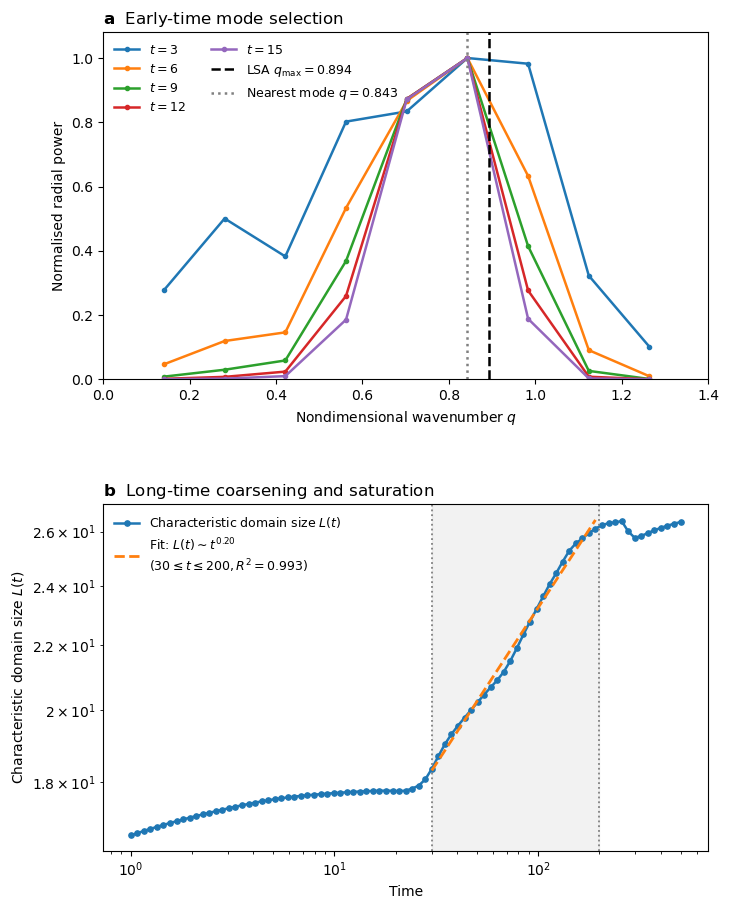

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# minimal-signalling CMIPS.
# Simulation 1: early-time radially averaged power spectrum.
# Simulation 2: long-time coarsening.
# The simulations run independently and are combined only at the plotting stage.

# Shared model parameters
Nx, Ny = 100, 100
dx = 1.0
dt = 0.001

phi_m = 0.9
phi0 = 0.8

M0 = 5.0
Pe_R = 0.001
kappa = 5.0

chi0 = 2.5
D_c = 1.0

k = 0.5 / kappa
S = 0.5 / kappa

phi_noise = 0.002
c_noise = 0.002

alpha0 = M0 / D_c
Da0 = k * kappa / D_c
PeC = chi0 / M0

print("Model: minimal-signalling CMIPS")
print(f"alpha0 = {alpha0:.4f}")
print(f"Da0    = {Da0:.4f}")
print(f"PeC    = {PeC:.4f}")

# Shared numerical operators
def laplacian(field, spacing):
    return (np.roll(field, -1, axis=0) + np.roll(field, 1, axis=0) + np.roll(field, -1, axis=1) + np.roll(field, 1, axis=1) - 4.0 * field) / spacing**2

def gradient_x(field, spacing):
    return (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2.0 * spacing)

def gradient_y(field, spacing):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2.0 * spacing)

def compute_mu(phi):
    phi_safe = np.clip(phi, 1e-6, phi_m - 1e-6)
    term1 = np.log(phi_safe)
    term2 = (1.0 - 2.0 * phi_safe - 0.3 * phi_safe**2)
    term3 = (-(4.0 / np.pi) * Pe_R * phi_m * (np.log(1.0 - phi_safe / phi_m) - phi_safe / phi_m - phi_safe))

    return term1 + term2 + term3

def radial_power_spectrum(field):
    fluctuation = field - np.mean(field)

    fft_field = np.fft.fft2(fluctuation)
    power_2d = np.abs(fft_field)**2

    qx = 2.0 * np.pi * np.fft.fftfreq(field.shape[0], d=dx)
    qy = 2.0 * np.pi * np.fft.fftfreq(field.shape[1], d=dx)

    QX, QY = np.meshgrid(qx, qy, indexing="ij")
    q_radius = np.sqrt(QX**2 + QY**2)
    dq = 2.0 * np.pi / (Nx * dx)

    radial_bin = np.rint(q_radius / dq).astype(int)

    shell_power = np.bincount(radial_bin.ravel(), weights=power_2d.ravel())
    shell_count = np.bincount(radial_bin.ravel())

    radial_average = (shell_power / np.maximum(shell_count, 1))

    q_simulation = (np.arange(len(radial_average)) * dq)
    q_nondimensional = (np.sqrt(kappa) * q_simulation)

    shell_power[0] = 0.0

    radial_average[0] = 0.0

    return (q_simulation, q_nondimensional, shell_power, radial_average)

# LSA prediction
def dmu_h(phi):
    return (1.0 / phi - 2.0 - 0.6 * phi - (4.0 / np.pi) * Pe_R * phi_m * (phi - 2.0 * phi_m) / (phi - phi_m)**2)

dmu = dmu_h(phi0)

def omega_minimal(q, alpha0, Da0, PeC):
    A = phi0 * q**2 * (dmu + q**2)
    B = PeC * phi0 * q**2
    C = 1.0
    D = (q**2 + Da0) / alpha0

    discriminant = ((A - D)**2 + 4.0 * B * C)
    root = np.sqrt(discriminant.astype(complex))
    omega_plus = 0.5 * (-(A + D) + root)

    return omega_plus

q_lsa = np.linspace(1e-5, 2.0, 200000)
growth_rate = omega_minimal(q_lsa, alpha0, Da0, PeC).real

max_index = np.argmax(growth_rate)
q_max_lsa = q_lsa[max_index]

unstable_mask = growth_rate > 0

if np.any(unstable_mask):
    q_unstable_max = q_lsa[unstable_mask][-1]

else:
    q_unstable_max = np.nan

L_box = Nx * dx
dq_simulation = (2.0 * np.pi / L_box)
dq_nondimensional = (np.sqrt(kappa) * dq_simulation)
nearest_mode_number = int(round(q_max_lsa / dq_nondimensional))
q_nearest_discrete = (nearest_mode_number * dq_nondimensional)

print("\nLSA prediction")
print(f"q_max LSA        = {q_max_lsa:.6f}")
print(f"nearest mode q   = {q_nearest_discrete:.6f}")
print(f"nearest mode no. = {nearest_mode_number}")

# Simulation 1: early-time power spectrum
print("Simulation 1: early-time spectrum")

rng_short = np.random.default_rng(1)

snapshot_times = [3.0, 6.0, 9.0, 12.0, 15.0]
t_final_short = max(snapshot_times)
n_steps_short = int(round(t_final_short / dt))

snapshot_steps = {int(round(time / dt)): time for time in snapshot_times}

phi_short = (phi0 + phi_noise * (rng_short.random((Nx, Ny)) - 0.5))

c0 = S * phi0 / k
c_short = (c0 + c_noise * (rng_short.random((Nx, Ny)) - 0.5))
phi_short = np.clip(phi_short, 1e-6, phi_m - 1e-6)
c_short = np.clip(c_short, 0.0, None)

snapshots = {}

for step in range(1, n_steps_short + 1):
    mu = compute_mu(phi_short)
    mu_eff = (mu - kappa * laplacian(phi_short, dx))

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    grad_c_x = gradient_x(c_short, dx)
    grad_c_y = gradient_y(c_short, dx)

    flux_mips_x = (M0 * phi_short * grad_mu_x)
    flux_mips_y = (M0 * phi_short * grad_mu_y)
    flux_chem_x = (-chi0 * phi_short * grad_c_x)
    flux_chem_y = (-chi0 * phi_short * grad_c_y)

    flux_x = (flux_mips_x + flux_chem_x)
    flux_y = (flux_mips_y + flux_chem_y)

    div_flux = (gradient_x(flux_x, dx) + gradient_y(flux_y, dx))

    phi_new = (phi_short + dt * div_flux)

    c_new = (c_short + dt * (D_c * laplacian(c_short, dx) - k * c_short + S * phi_short))

    phi_short = np.clip(phi_new, 1e-6, phi_m - 1e-6)
    c_short = np.clip(c_new, 0.0, None)

    if step in snapshot_steps:
        saved_time = snapshot_steps[step]
        snapshots[saved_time] = (phi_short.copy())
        print(f"Saved t = {saved_time:4.1f} | " f"variance = " f"{np.var(phi_short):.8e}")

spectrum_results = {}

print("\nFourier-spectrum peaks")
print("time      q_peak       " "q_max LSA      difference")

for time in snapshot_times:
    (q_simulation, q_values, shell_power, radial_power) = radial_power_spectrum(snapshots[time])

    valid = ((q_values > 0) & (q_values <= q_unstable_max))

    q_search = q_values[valid]
    power_search = radial_power[valid]

    peak_index = np.argmax(power_search)
    q_peak = q_search[peak_index]

    spectrum_results[time] = {"q": q_values, "power": radial_power, "q_peak": q_peak}
    print(f"{time:4.1f}      " f"{q_peak:8.5f}      " f"{q_max_lsa:8.5f}      " f"{abs(q_peak - q_max_lsa):8.5f}")
print("Simulation 1 complete.")

# Simulation 2: long-time coarsening

print("Simulation 2: long-time coarsening")


rng_long = np.random.default_rng(1)
t_final_long = 500.0
n_steps_long = int(round(t_final_long / dt))

sample_times = np.unique(np.round(np.geomspace(1.0, t_final_long, 85), 3))
sample_times = np.unique(np.append(sample_times, t_final_long))

sample_steps = {int(round(time / dt)): float(time) for time in sample_times}

def calculate_characteristic_length(field, q_upper=1.4):
    (q_simulation, q_nondimensional, shell_power, radial_average) = radial_power_spectrum(field)

    valid = ((q_nondimensional > 0) & (q_nondimensional <= q_upper) & np.isfinite(shell_power))
    q_sim = q_simulation[valid]
    power_shell = shell_power[valid]

    total_power = np.sum(power_shell)

    if total_power <= 0:
        return np.nan, np.nan

    q_mean_simulation = (np.sum(q_sim * power_shell) / total_power)
    q_mean_nondimensional = (np.sqrt(kappa) * q_mean_simulation)
    L_characteristic = (2.0 * np.pi / q_mean_simulation)

    return (L_characteristic, q_mean_nondimensional)

phi_long = (phi0 + phi_noise * (rng_long.random((Nx, Ny)) - 0.5))
c_long = (c0 + c_noise * (rng_long.random((Nx, Ny)) - 0.5))

recorded_times = []
L_history = []

for step in range(1, n_steps_long + 1):
    mu = compute_mu(phi_long)
    mu_eff = (mu - kappa * laplacian(phi_long, dx))

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    grad_c_x = gradient_x(c_long, dx)
    grad_c_y = gradient_y(c_long, dx)

    flux_x = (M0 * phi_long * grad_mu_x - chi0 * phi_long * grad_c_x)
    flux_y = (M0 * phi_long * grad_mu_y - chi0 * phi_long * grad_c_y)

    div_flux = (gradient_x(flux_x, dx) + gradient_y(flux_y, dx))

    phi_new = (phi_long + dt * div_flux)

    c_new = (c_long + dt * (D_c * laplacian(c_long, dx) - k * c_long + S * phi_long))

    # Exactly as in the original long-time code
    phi_long = np.clip(phi_new, 0.0, 1.0)
    c_long = np.clip(c_new, 0.0, None)

    if step in sample_steps:
        current_time = (sample_steps[step])
        (L_characteristic, q_mean) = calculate_characteristic_length(phi_long)
        recorded_times.append(current_time)
        L_history.append(L_characteristic)
        print(f"t = {current_time:8.3f} | " f"L = {L_characteristic:8.3f} | " f"q_mean = {q_mean:6.3f}")
print("Simulation 2 complete.")

recorded_times = np.asarray(recorded_times)
L_history = np.asarray(L_history)

# Power-law fitting range
fit_t_min = 30.0
fit_t_max = 200.0

fit_mask = ((recorded_times >= fit_t_min) & (recorded_times <= fit_t_max) & np.isfinite(L_history) & (L_history > 0))

times_fit = recorded_times[fit_mask]
L_fit_data = L_history[fit_mask]

if len(times_fit) >= 3:
    beta, log_prefactor = np.polyfit(np.log(times_fit), np.log(L_fit_data), 1)

    prefactor = np.exp(log_prefactor)
    fitted_L = (prefactor * times_fit**beta)

    log_L_observed = np.log(L_fit_data)
    log_L_predicted = (log_prefactor + beta * np.log(times_fit))

    residual_sum_squares = np.sum((log_L_observed - log_L_predicted)**2)
    total_sum_squares = np.sum((log_L_observed - np.mean(log_L_observed))**2)

    fit_r2 = (1.0 - residual_sum_squares / total_sum_squares)

    print("\nPower-law fit")
    print(f"Fit range: " f"{fit_t_min:.1f} " f"<= t <= " f"{fit_t_max:.1f}")
    print(f"beta = {beta:.4f}")
    print(f"R^2  = {fit_r2:.4f}")

else:
    beta = np.nan

    fit_r2 = np.nan
    fitted_L = None
    print("Not enough valid points " "for fitting.")

# FINAL PLOTTING
# The two completed simulations are combined only here.
fig, axes = plt.subplots(2, 1, figsize=(7.2, 9.2))
ax_spectrum = axes[0]
ax_coarsening = axes[1]

# Panel a: early-time spectrum
for time in snapshot_times:
    q_values = (spectrum_results[time]["q"])
    radial_power = (spectrum_results[time]["power"])

    valid = ((q_values > 0) & (q_values <= 1.4))

    q_plot = q_values[valid]
    power_plot = (radial_power[valid])

    max_power = np.max(power_plot)

    if max_power > 0:
        power_plot = (power_plot / max_power)

    ax_spectrum.plot(q_plot, power_plot, marker="o", markersize=3, linewidth=1.8, label=rf"$t={time:g}$")
ax_spectrum.axvline(q_max_lsa, color="black", linestyle="--", linewidth=1.8, label=(rf"LSA " rf"$q_{{\max}}=" rf"{q_max_lsa:.3f}$"))
ax_spectrum.axvline(q_nearest_discrete, color="grey", linestyle=":", linewidth=1.8, label=(rf"Nearest mode " rf"$q=" rf"{q_nearest_discrete:.3f}$"))

ax_spectrum.set_xlim(0, 1.4)
ax_spectrum.set_ylim(0, 1.08)

ax_spectrum.set_xlabel(r"Nondimensional wavenumber $q$")
ax_spectrum.set_ylabel("Normalised radial power")

ax_spectrum.set_title(r"$\mathbf{a}$  " r"Early-time mode selection", loc="left")
ax_spectrum.legend(frameon=False, ncol=2, fontsize=9, loc="upper left")

# Panel b: long-time coarsening
ax_coarsening.loglog(recorded_times, L_history, marker="o", markersize=3.8, linewidth=1.8, label=(r"Characteristic domain " r"size $L(t)$"))

# Mark the fitting interval
ax_coarsening.axvspan(fit_t_min, fit_t_max, color="grey", alpha=0.10, zorder=0)
ax_coarsening.axvline(fit_t_min, color="grey", linestyle=":", linewidth=1.3)
ax_coarsening.axvline(fit_t_max, color="grey", linestyle=":", linewidth=1.3)

if fitted_L is not None:
    ax_coarsening.loglog(times_fit, fitted_L, linestyle="--", linewidth=2.0, label=(rf"Fit: " rf"$L(t)\sim " rf"t^{{{beta:.2f}}}$" "\n" rf"$(" rf"{fit_t_min:.0f}" rf"\leq t\leq" rf"{fit_t_max:.0f}, " rf"R^2={fit_r2:.3f})$"))

ax_coarsening.set_xlabel("Time")
ax_coarsening.set_ylabel(r"Characteristic domain size $L(t)$")

ax_coarsening.set_title(r"$\mathbf{b}$  " r"Long-time coarsening and saturation", loc="left")
ax_coarsening.legend(frameon=False, fontsize=9, loc="upper left")

# Layout
fig.subplots_adjust(left=0.13, right=0.97, bottom=0.08, top=0.97, hspace=0.36)


plt.show()


In [ ]:
### Autocrine-signalling MIPS

Model: autocrine CMIPS
alpha0 = 5.0000
Da0    = 0.5000
PeC    = 0.5000
(Note: autocrine linear LSA is independent of PeC at first order.)

LSA prediction (autocrine)
q_max (simulation units)      = 0.333977
q_max (nondimensional figure) = 0.746795
nearest mode q                = 0.702481
nearest mode no.              = 5

Simulation 1: early-time spectrum
Saved t =  3.0 | variance = 2.56504868e-08
Saved t =  6.0 | variance = 1.01707470e-07
Saved t =  9.0 | variance = 4.53355864e-07
Saved t = 12.0 | variance = 2.15525110e-06
Saved t = 15.0 | variance = 1.06729750e-05

Fourier-spectrum peaks
time      q_peak       q_max LSA      difference
 3.0       0.84298       0.74680       0.09618
 6.0       0.84298       0.74680       0.09618
 9.0       0.70248       0.74680       0.04431
12.0       0.70248       0.74680       0.04431
15.0       0.70248       0.74680       0.04431
Simulation 1 complete.

Simulation 2: long-time coarsening
t =    1.000 | L =   16.730 | q_mean =  0.840
t =    1.077 |

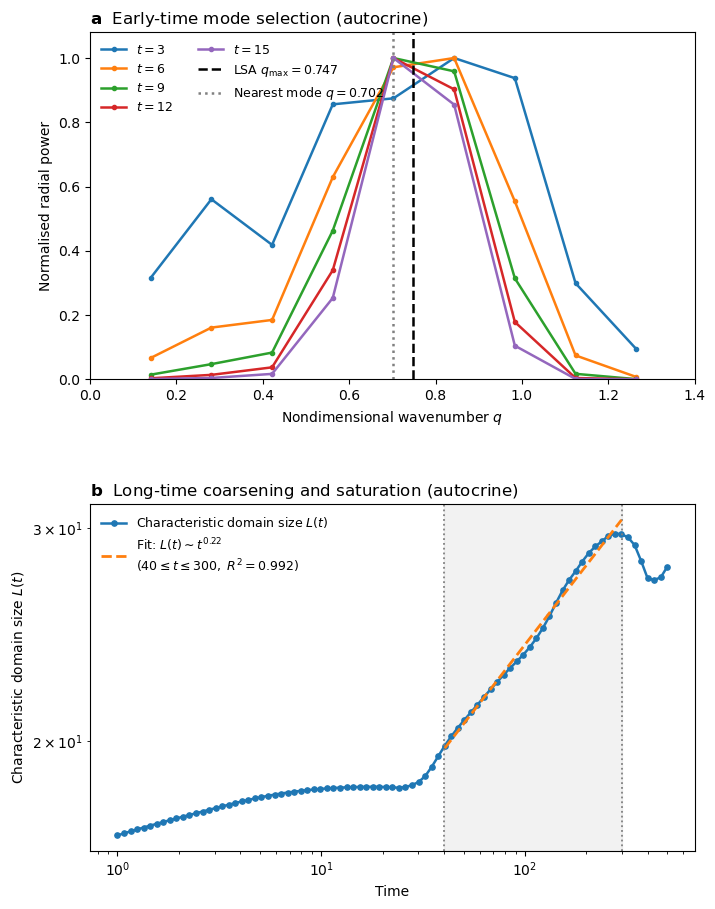

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Combined spinodal-decomposition figure: autocrine CMIPS.
# Top: early-time radially averaged power spectrum.
# Bottom: long-time coarsening.
# The simulations run independently and are combined only at the plotting stage.

# Shared model parameters
Nx, Ny = 100, 100
dx = 1.0
dt = 0.001

phi_m = 0.9
phi0 = 0.8

M0 = 5.0
Pe_R = 0.001
kappa = 5.0

chi0 = 2.5
D_c = 1.0

# Choose k so that Da0 = kappa * k / D_c = 0.5
k = 0.5 / kappa
S = 0.5 / kappa

phi_noise = 0.002
c_noise = 0.002

alpha0 = M0 / D_c
Da0 = k * kappa / D_c
PeC = chi0 / M0

print("Model: autocrine CMIPS")
print(f"alpha0 = {alpha0:.4f}")
print(f"Da0    = {Da0:.4f}")
print(f"PeC    = {PeC:.4f}")
print("(Note: autocrine linear LSA is independent of PeC at first order.)")

# Shared numerical operators
def laplacian(field, spacing):
    return (np.roll(field, -1, axis=0) + np.roll(field, 1, axis=0) + np.roll(field, -1, axis=1) + np.roll(field, 1, axis=1) - 4.0 * field) / spacing**2

def gradient_x(field, spacing):
    return (np.roll(field, -1, axis=0) - np.roll(field, 1, axis=0)) / (2.0 * spacing)

def gradient_y(field, spacing):
    return (np.roll(field, -1, axis=1) - np.roll(field, 1, axis=1)) / (2.0 * spacing)

def compute_mu(phi):
    phi_safe = np.clip(phi, 1e-6, phi_m - 1e-6)
    term1 = np.log(phi_safe)
    term2 = 1.0 - 2.0 * phi_safe - 0.3 * phi_safe**2
    term3 = (-(4.0 / np.pi) * Pe_R * phi_m * (np.log(1.0 - phi_safe / phi_m) - phi_safe / phi_m - phi_safe))

    return term1 + term2 + term3

def radial_power_spectrum(field):
    fluctuation = field - np.mean(field)

    fft_field = np.fft.fft2(fluctuation)
    power_2d = np.abs(fft_field) ** 2

    qx = 2.0 * np.pi * np.fft.fftfreq(field.shape[0], d=dx)
    qy = 2.0 * np.pi * np.fft.fftfreq(field.shape[1], d=dx)

    QX, QY = np.meshgrid(qx, qy, indexing="ij")
    q_radius = np.sqrt(QX**2 + QY**2)

    dq = 2.0 * np.pi / (Nx * dx)

    radial_bin = np.rint(q_radius / dq).astype(int)

    shell_power = np.bincount(radial_bin.ravel(), weights=power_2d.ravel())

    shell_count = np.bincount(radial_bin.ravel())

    radial_average = shell_power / np.maximum(shell_count, 1)

    q_simulation = np.arange(len(radial_average)) * dq
    q_nondimensional = np.sqrt(kappa) * q_simulation

    shell_power[0] = 0.0
    radial_average[0] = 0.0

    return q_simulation, q_nondimensional, shell_power, radial_average

# Autocrine LSA
# Using the same form as in Figure 2 (autocrine MIPS panel)
def dmu_h(phi):
    return (1.0 / phi - 2.0 - 0.6 * phi - (4.0 / np.pi) * Pe_R * phi_m * (phi - 2.0 * phi_m) / (phi - phi_m) ** 2)

dmu = dmu_h(phi0)

def omega_autocrine_dim(q, M0, k_val):
    """
    Positive branch used previously for autocrine MIPS.
    q here is the dimensional simulation wavenumber.
    """
    M = M0 * q**2 * (dmu + kappa * q**2)
    D = D_c * q**2 + k_val * phi0

    disc = (M - D) ** 2
    omega_plus = 0.5 * (-(M + D) + np.sqrt(disc.astype(complex)))

    return omega_plus

# Search q in the simulation (dimensional) variable
q_lsa_sim = np.linspace(1e-5, 1.5, 200000)
growth_rate = omega_autocrine_dim(q_lsa_sim, M0=M0, k_val=k).real

max_index = np.argmax(growth_rate)
q_max_sim = q_lsa_sim[max_index]

unstable_mask = growth_rate > 0
if np.any(unstable_mask):
    q_unstable_max_sim = q_lsa_sim[unstable_mask][-1]
else:
    q_unstable_max_sim = np.nan

# Convert to the nondimensional q used in the figures
q_max_lsa = np.sqrt(kappa) * q_max_sim
q_unstable_max = np.sqrt(kappa) * q_unstable_max_sim

L_box = Nx * dx
dq_simulation = 2.0 * np.pi / L_box
dq_nondimensional = np.sqrt(kappa) * dq_simulation

nearest_mode_number = int(round(q_max_lsa / dq_nondimensional))
q_nearest_discrete = nearest_mode_number * dq_nondimensional

print("\nLSA prediction (autocrine)")
print(f"q_max (simulation units)      = {q_max_sim:.6f}")
print(f"q_max (nondimensional figure) = {q_max_lsa:.6f}")
print(f"nearest mode q                = {q_nearest_discrete:.6f}")
print(f"nearest mode no.              = {nearest_mode_number}")

# Simulation 1: early-time power spectrum
print("Simulation 1: early-time spectrum")

rng_short = np.random.default_rng(1)

snapshot_times = [3.0, 6.0, 9.0, 12.0, 15.0]
t_final_short = max(snapshot_times)
n_steps_short = int(round(t_final_short / dt))

snapshot_steps = {int(round(time / dt)): time for time in snapshot_times}

phi_short = phi0 + phi_noise * (rng_short.random((Nx, Ny)) - 0.5)

# Autocrine homogeneous steady state:
# -k*phi0*c0 + S*phi0 = 0  =>  c0 = S/k
c0 = S / k

c_short = c0 + c_noise * (rng_short.random((Nx, Ny)) - 0.5)

phi_short = np.clip(phi_short, 1e-6, phi_m - 1e-6)
c_short = np.clip(c_short, 0.0, None)

snapshots = {}

for step in range(1, n_steps_short + 1):
    mu = compute_mu(phi_short)
    mu_eff = mu - kappa * laplacian(phi_short, dx)

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    grad_c_x = gradient_x(c_short, dx)
    grad_c_y = gradient_y(c_short, dx)

    flux_mips_x = M0 * phi_short * grad_mu_x
    flux_mips_y = M0 * phi_short * grad_mu_y

    flux_chem_x = -chi0 * phi_short * grad_c_x
    flux_chem_y = -chi0 * phi_short * grad_c_y

    flux_x = flux_mips_x + flux_chem_x
    flux_y = flux_mips_y + flux_chem_y

    div_flux = gradient_x(flux_x, dx) + gradient_y(flux_y, dx)

    phi_new = phi_short + dt * div_flux

    # Autocrine chemical update
    c_new = c_short + dt * (D_c * laplacian(c_short, dx) - k * phi_short * c_short + S * phi_short)

    phi_short = np.clip(phi_new, 1e-6, phi_m - 1e-6)
    c_short = np.clip(c_new, 0.0, None)

    if step in snapshot_steps:
        saved_time = snapshot_steps[step]
        snapshots[saved_time] = phi_short.copy()

        print(f"Saved t = {saved_time:4.1f} | " f"variance = {np.var(phi_short):.8e}")

spectrum_results = {}

print("\nFourier-spectrum peaks")
print("time      q_peak       q_max LSA      difference")

for time in snapshot_times:
    q_simulation, q_values, shell_power, radial_power = radial_power_spectrum(snapshots[time])

    valid = ((q_values > 0) & (q_values <= q_unstable_max))

    q_search = q_values[valid]
    power_search = radial_power[valid]

    peak_index = np.argmax(power_search)
    q_peak = q_search[peak_index]

    spectrum_results[time] = {"q": q_values, "power": radial_power, "q_peak": q_peak}

    print(f"{time:4.1f}      " f"{q_peak:8.5f}      " f"{q_max_lsa:8.5f}      " f"{abs(q_peak - q_max_lsa):8.5f}")

print("Simulation 1 complete.")

# Simulation 2: long-time coarsening
print("Simulation 2: long-time coarsening")

rng_long = np.random.default_rng(1)

t_final_long = 500.0
n_steps_long = int(round(t_final_long / dt))

sample_times = np.unique(np.round(np.geomspace(1.0, t_final_long, 85), 3))
sample_times = np.unique(np.append(sample_times, t_final_long))

sample_steps = {int(round(time / dt)): float(time) for time in sample_times}

def calculate_characteristic_length(field, q_upper=1.4):
    q_simulation, q_nondimensional, shell_power, radial_average = radial_power_spectrum(field)

    valid = ((q_nondimensional > 0) & (q_nondimensional <= q_upper) & np.isfinite(shell_power))

    q_sim = q_simulation[valid]
    power_shell = shell_power[valid]

    total_power = np.sum(power_shell)
    if total_power <= 0:
        return np.nan, np.nan

    q_mean_simulation = np.sum(q_sim * power_shell) / total_power
    q_mean_nondimensional = np.sqrt(kappa) * q_mean_simulation

    L_characteristic = 2.0 * np.pi / q_mean_simulation

    return L_characteristic, q_mean_nondimensional

phi_long = phi0 + phi_noise * (rng_long.random((Nx, Ny)) - 0.5)
c_long = c0 + c_noise * (rng_long.random((Nx, Ny)) - 0.5)

recorded_times = []
L_history = []

for step in range(1, n_steps_long + 1):
    mu = compute_mu(phi_long)
    mu_eff = mu - kappa * laplacian(phi_long, dx)

    grad_mu_x = gradient_x(mu_eff, dx)
    grad_mu_y = gradient_y(mu_eff, dx)

    grad_c_x = gradient_x(c_long, dx)
    grad_c_y = gradient_y(c_long, dx)

    flux_x = (M0 * phi_long * grad_mu_x - chi0 * phi_long * grad_c_x)

    flux_y = (M0 * phi_long * grad_mu_y - chi0 * phi_long * grad_c_y)

    div_flux = gradient_x(flux_x, dx) + gradient_y(flux_y, dx)

    phi_new = phi_long + dt * div_flux

    # Autocrine chemical update
    c_new = c_long + dt * (D_c * laplacian(c_long, dx) - k * phi_long * c_long + S * phi_long)

    # keep same long-time style as your minimal-signalling code
    phi_long = np.clip(phi_new, 0.0, 1.0)
    c_long = np.clip(c_new, 0.0, None)

    if step in sample_steps:
        current_time = sample_steps[step]

        L_characteristic, q_mean = calculate_characteristic_length(phi_long)

        recorded_times.append(current_time)
        L_history.append(L_characteristic)

        print(f"t = {current_time:8.3f} | " f"L = {L_characteristic:8.3f} | " f"q_mean = {q_mean:6.3f}")

print("Simulation 2 complete.")

recorded_times = np.asarray(recorded_times)
L_history = np.asarray(L_history)

# Power-law fitting range
fit_t_min = 40
fit_t_max = 300

fit_mask = ((recorded_times >= fit_t_min) & (recorded_times <= fit_t_max) & np.isfinite(L_history) & (L_history > 0))

times_fit = recorded_times[fit_mask]
L_fit_data = L_history[fit_mask]

if len(times_fit) >= 3:
    beta, log_prefactor = np.polyfit(np.log(times_fit), np.log(L_fit_data), 1)

    prefactor = np.exp(log_prefactor)
    fitted_L = prefactor * times_fit**beta

    log_L_observed = np.log(L_fit_data)
    log_L_predicted = log_prefactor + beta * np.log(times_fit)

    residual_sum_squares = np.sum((log_L_observed - log_L_predicted) ** 2)
    total_sum_squares = np.sum((log_L_observed - np.mean(log_L_observed)) ** 2)

    fit_r2 = 1.0 - residual_sum_squares / total_sum_squares

    print("\nPower-law fit")
    print(f"Fit range: {fit_t_min:.1f} <= t <= {fit_t_max:.1f}")
    print(f"beta = {beta:.4f}")
    print(f"R^2  = {fit_r2:.4f}")

else:
    beta = np.nan
    fit_r2 = np.nan
    fitted_L = None
    print("Not enough valid points for fitting.")

# FINAL PLOTTING
fig, axes = plt.subplots(2, 1, figsize=(7.2, 9.2))

ax_spectrum = axes[0]
ax_coarsening = axes[1]

# Panel a: early-time spectrum
for time in snapshot_times:
    q_values = spectrum_results[time]["q"]
    radial_power = spectrum_results[time]["power"]

    valid = ((q_values > 0) & (q_values <= 1.4))

    q_plot = q_values[valid]
    power_plot = radial_power[valid]

    max_power = np.max(power_plot)
    if max_power > 0:
        power_plot = power_plot / max_power

    ax_spectrum.plot(q_plot, power_plot, marker="o", markersize=3, linewidth=1.8, label=rf"$t={time:g}$")

ax_spectrum.axvline(q_max_lsa, color="black", linestyle="--", linewidth=1.8, label=rf"LSA $q_{{\max}}={q_max_lsa:.3f}$")

ax_spectrum.axvline(q_nearest_discrete, color="grey", linestyle=":", linewidth=1.8, label=rf"Nearest mode $q={q_nearest_discrete:.3f}$")

ax_spectrum.set_xlim(0, 1.4)
ax_spectrum.set_ylim(0, 1.08)

ax_spectrum.set_xlabel(r"Nondimensional wavenumber $q$")
ax_spectrum.set_ylabel("Normalised radial power")

ax_spectrum.set_title(r"$\mathbf{a}$  Early-time mode selection (autocrine)", loc="left")

ax_spectrum.legend(frameon=False, ncol=2, fontsize=9, loc="upper left")

# Panel b: long-time coarsening
ax_coarsening.loglog(recorded_times, L_history, marker="o", markersize=3.8, linewidth=1.8, label=r"Characteristic domain size $L(t)$")

# fit interval
ax_coarsening.axvspan(fit_t_min, fit_t_max, color="grey", alpha=0.10, zorder=0)

ax_coarsening.axvline(fit_t_min, color="grey", linestyle=":", linewidth=1.3)

ax_coarsening.axvline(fit_t_max, color="grey", linestyle=":", linewidth=1.3)

if fitted_L is not None:
    ax_coarsening.loglog(times_fit, fitted_L, linestyle="--", linewidth=2.0, label=(rf"Fit: $L(t)\sim t^{{{beta:.2f}}}$" "\n" rf"$({fit_t_min:.0f}\leq t\leq{fit_t_max:.0f},\ R^2={fit_r2:.3f})$"))

ax_coarsening.set_xlabel("Time")
ax_coarsening.set_ylabel(r"Characteristic domain size $L(t)$")

ax_coarsening.set_title(r"$\mathbf{b}$  Long-time coarsening and saturation (autocrine)", loc="left")

ax_coarsening.legend(frameon=False, fontsize=9, loc="upper left")

# Layout
fig.subplots_adjust(left=0.13, right=0.97, bottom=0.08, top=0.97, hspace=0.36)

plt.show()